In [1]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from utils_data_vis import *
from utils_graphs import read_data

plt.style.use("seaborn-v0_8-colorblind")

datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"

# Horas críticas (Beiró & Gandica et al.)
HORA_CRITICA_NAT, HORA_CRITICA_9N, HORA_CRITICA_CH = "429624", "437037", "394717"

CTW_WINDOWS = {
    "nat": {"inicio": 45, "final": 140, "hora_critica": HORA_CRITICA_NAT},
    "9n": {"inicio": 0, "final": 140, "hora_critica": HORA_CRITICA_9N},
    "ch": {"inicio": 206, "final": 293, "hora_critica": HORA_CRITICA_CH},
}

HOUR_WINDOWS_TABLE = list(range(1, 9))  # 1, 2, ..., 8
METRIC_COLS = [
    "Usuarios únicos",
    "Hashtags únicos",
    "Aristas (nodos hashtag)",
    "Aristas (nodos user)",
]

In [2]:
EDGE_CRITERIA = {"hashtag": "user", "user": "hashtag"}


def get_block_start(df, hora_critica, hour_window):
    hours = np.sort(df["hour"].unique())
    for hour_start in hours[::hour_window]:
        block = [hour_start + step for step in range(hour_window)]
        if hora_critica in block:
            return hour_start, block
    return None, None


def build_graph_block(df_hour, node_criteria, edge_criteria):
    G = nx.Graph()
    df_nodes = df_hour[node_criteria].unique()
    G.add_nodes_from(df_nodes)
    for node in df_nodes:
        df_node_edge = df_hour.loc[df_hour[node_criteria] == node, edge_criteria].drop_duplicates()
        for edge in df_node_edge:
            df_edge = df_hour.loc[df_hour[edge_criteria] == edge, node_criteria].drop_duplicates()
            for nd in df_edge:
                if nd != node:
                    if G.has_edge(node, nd):
                        G[node][nd]["weight"] += 1
                    else:
                        G.add_edge(node, nd, weight=1)
    for edge in G.edges():
        old_weight = G.edges[edge]["weight"]
        nx.set_edge_attributes(G, {edge: {"weight": old_weight / 2}})
    return G


def get_graph_edges(manifestacion, hour_start, hour_window, node_criteria, df):
    path = f"{graphs_folder}nodes_{node_criteria}/{manifestacion}/{hour_window}/{hour_start}.gexf"
    if os.path.exists(path) and os.path.getsize(path) > 0:
        try:
            return nx.read_gexf(path).number_of_edges()
        except Exception:
            pass
    conditions = df["hour"] == hour_start
    for step in range(1, hour_window):
        conditions |= df["hour"] == hour_start + step
    G = build_graph_block(df[conditions], node_criteria, EDGE_CRITERIA[node_criteria])
    return G.number_of_edges()


def get_edges_timeseries(df, manifestacion, hour_window, node_criteria):
    hour_starts = np.sort(df["hour"].unique())[::hour_window]
    return [
        get_graph_edges(manifestacion, hour_start, hour_window, node_criteria, df)
        for hour_start in hour_starts
    ]

In [3]:
def get_critical_hour_counts(manifestacion, hour_window):
    cfg = CTW_WINDOWS[manifestacion]
    hora_critica = int(cfg["hora_critica"])
    df = read_data(manifestacion, datasets_folder=datasets_folder)
    hour_start, horas_ventana = get_block_start(df, hora_critica, hour_window)
    if hour_start is None:
        return None

    hour_starts = np.sort(df["hour"].unique())[::hour_window]
    idx = list(hour_starts).index(hour_start)
    num_users, num_hashtags = get_num_users_hashtags(df, hour_window=hour_window)
    return {
        "manifestacion": manifestacion.upper(),
        "hora_critica": hora_critica,
        "hour_window": hour_window,
        "horas_ventana": horas_ventana,
        "usuarios": num_users[idx],
        "hashtags": num_hashtags[idx],
        "aristas_hashtag": get_graph_edges(manifestacion, hour_start, hour_window, "hashtag", df),
        "aristas_user": get_graph_edges(manifestacion, hour_start, hour_window, "user", df),
    }


def build_critical_hour_table():
    rows = []
    for manifestacion in ["nat", "9n", "ch"]:
        for hour_window in HOUR_WINDOWS_TABLE:
            counts = get_critical_hour_counts(manifestacion, hour_window)
            rows.append({
                "Manifestación": counts["manifestacion"],
                "Hora crítica": counts["hora_critica"],
                "Ventana (h)": counts["hour_window"],
                "Horas incluidas": ", ".join(str(h) for h in counts["horas_ventana"]),
                "Usuarios únicos": counts["usuarios"],
                "Hashtags únicos": counts["hashtags"],
                "Aristas (nodos hashtag)": counts["aristas_hashtag"],
                "Aristas (nodos user)": counts["aristas_user"],
            })
    return pd.DataFrame(rows)


def build_critical_hour_table_pct(tabla=None):
    if tabla is None:
        tabla = build_critical_hour_table()
    pct = tabla.copy()
    pct[METRIC_COLS] = pct[METRIC_COLS].astype(float)
    for manifestacion in pct["Manifestación"].unique():
        mask = pct["Manifestación"] == manifestacion
        for col in METRIC_COLS:
            max_val = pct.loc[mask, col].max()
            pct.loc[mask, col] = (pct.loc[mask, col] / max_val * 100).round(2)
    return pct.rename(columns={col: f"{col} (%)" for col in METRIC_COLS})

In [4]:
def plot_users_hashtags_edges(manifestacion, hour_window, ax=None, legend=True):
    cfg = CTW_WINDOWS[manifestacion]
    df = read_data(manifestacion, datasets_folder=datasets_folder)
    hour_dt = np.sort(df["hour"].unique())[::hour_window]
    num_users, num_hashtags = get_num_users_hashtags(df, hour_window=hour_window)
    edges_hashtag = get_edges_timeseries(df, manifestacion, hour_window, "hashtag")
    edges_user = get_edges_timeseries(df, manifestacion, hour_window, "user")

    sl = slice(int(cfg["inicio"] / hour_window), int(cfg["final"] / hour_window))
    x = hour_dt[sl]

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(x, np.array(num_users)[sl], label="Unique users", color="orange")
    ax.plot(x, np.array(num_hashtags)[sl], label="Unique Hashtags", color="magenta")
    ax.set_ylabel("Cuenta única")
    ax.set_title(f"{manifestacion.upper()} — ventana {hour_window}h", fontsize=14)
    ax.get_xaxis().set_visible(False)

    ax2 = ax.twinx()
    ax2.plot(x, np.array(edges_hashtag)[sl], label="Aristas (nodos hashtag)", color="blue", alpha=0.7)
    ax2.plot(x, np.array(edges_user)[sl], label="Aristas (nodos user)", color="green", alpha=0.7)
    ax2.set_ylabel("Aristas")

    if legend:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="best", prop={"size": 8})

    return ax

## Resultados en las horas críticas

In [6]:
tabla_criticas = build_critical_hour_table()
tabla_criticas

In [8]:
tabla_criticas

,Manifestación,Hora crítica,Ventana (h),Horas incluidas,Usuarios únicos,Hashtags únicos,Aristas (nodos hashtag),Aristas (nodos user)
0,NAT,429624,1,429624,1374,642,4470,537866
1,NAT,429624,2,"429623, 429624",2072,1054,8985,1127987
2,NAT,429624,3,"429624, 429625, 429626",2615,1316,11515,1971243
3,NAT,429624,4,"429623, 429624, 429625, 429626",3215,1661,16242,2894620
4,NAT,429624,5,"429621, 429622, 429623, 429624, 429625",3123,1816,16588,2146680
5,NAT,429624,6,"429621, 429622, 429623, 429624, 429625, 429626",3593,2088,20224,3085013
6,NAT,429624,7,"429622, 429623, 429624, 429625, 429626, 429627...",3961,2212,21760,4188824
7,NAT,429624,8,"429619, 429620, 429621, 429622, 429623, 429624...",3866,2549,24760,3154136
8,9N,437037,1,437037,1444,870,9709,362948
9,9N,437037,2,"437037, 437038",2279,1327,21707,939660


## Porcentajes respecto al máximo (por manifestación)

In [7]:
tabla_criticas_pct = build_critical_hour_table_pct(tabla_criticas)
tabla_criticas_pct

,Manifestación,Hora crítica,Ventana (h),Horas incluidas,Usuarios únicos (%),Hashtags únicos (%),Aristas (nodos hashtag) (%),Aristas (nodos user) (%)
0,NAT,429624,1,429624,34.69,25.19,18.05,12.84
1,NAT,429624,2,"429623, 429624",52.31,41.35,36.29,26.93
2,NAT,429624,3,"429624, 429625, 429626",66.02,51.63,46.51,47.06
3,NAT,429624,4,"429623, 429624, 429625, 429626",81.17,65.16,65.60,69.10
4,NAT,429624,5,"429621, 429622, 429623, 429624, 429625",78.84,71.24,67.00,51.25
5,NAT,429624,6,"429621, 429622, 429623, 429624, 429625, 429626",90.71,81.91,81.68,73.65
6,NAT,429624,7,"429622, 429623, 429624, 429625, 429626, 429627...",100.00,86.78,87.88,100.00
7,NAT,429624,8,"429619, 429620, 429621, 429622, 429623, 429624...",97.60,100.00,100.00,75.30
8,9N,437037,1,437037,33.85,25.08,10.44,11.73
9,9N,437037,2,"437037, 437038",53.42,38.25,23.35,30.36


## Todos los datasets (NAT, 9N, CH)

KeyboardInterrupt: 

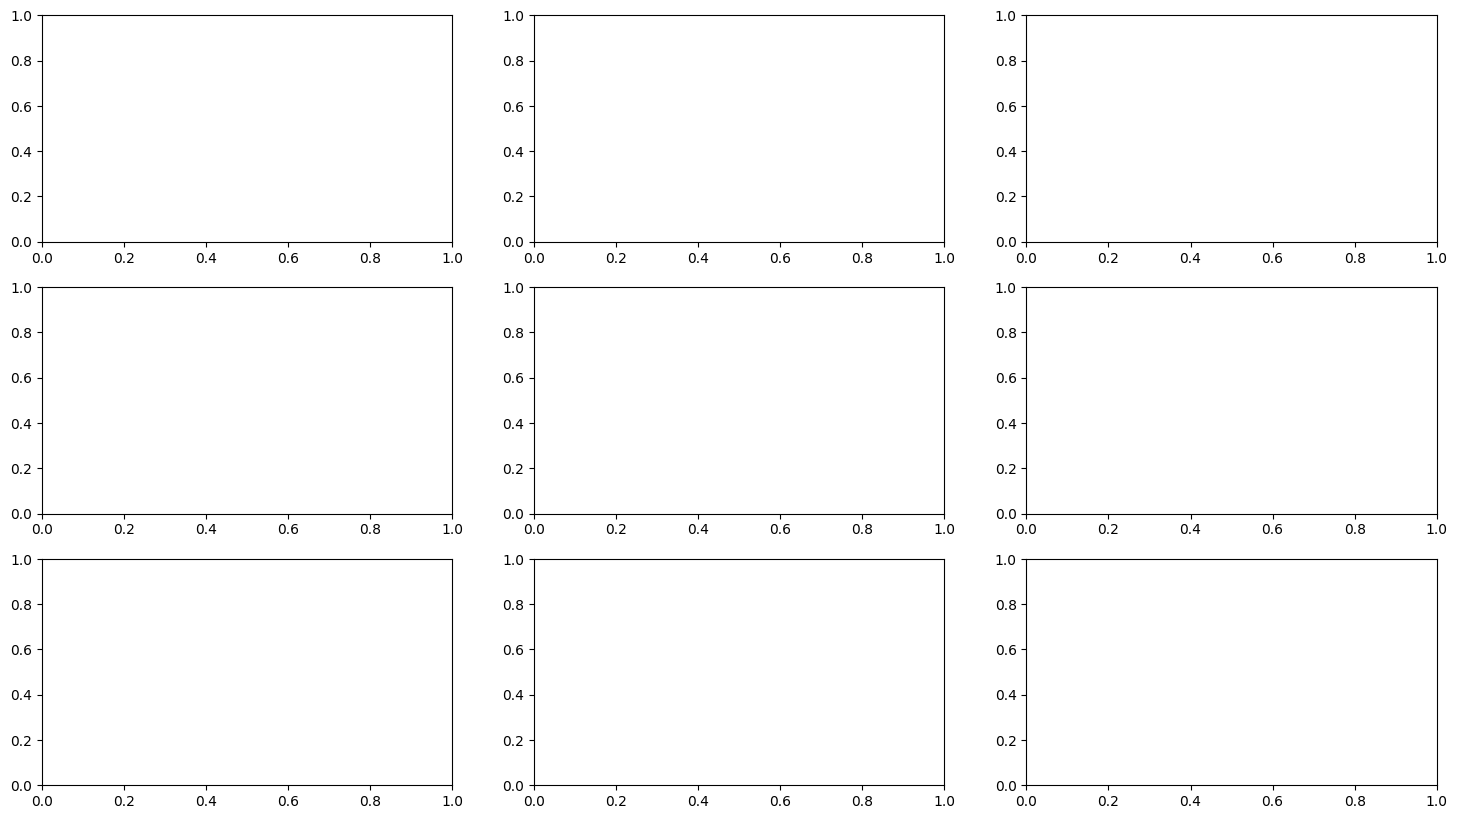

In [5]:
manifestaciones = ["nat", "9n", "ch"]
hour_windows = [1, 2, 3]

fig, axes = plt.subplots(len(manifestaciones), len(hour_windows), figsize=(18, 10))

for i, manifestacion in enumerate(manifestaciones):
    for j, hour_window in enumerate(hour_windows):
        plot_users_hashtags_edges(
            manifestacion,
            hour_window=hour_window,
            ax=axes[i, j],
            legend=(i == 0 and j == 0),
        )

plt.tight_layout()
plt.show()